In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/sample_submission.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/train.csv
/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/test.csv


# **Loading Datasets**

In [2]:
train_df = pd.read_csv("/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/train.csv")
test_df = pd.read_csv("/kaggle/input/mlp-term-3-2025-kaggle-assignment-2/test.csv")

In [3]:
train_df.head(3)

,id,adults,children,weekends,weekdays,meal_type,room_type,arrival,lead_time,segment,repeat,price,requests,booking_status
0,0,2,0,0,1,Not Selected,Room_Type 1,2018-05-21,54.0,Online,0,116.10,0,1
1,1,1,0,3,6,Not Selected,Room_Type 1,2018-11-12,12.0,Online,0,71.87,1,1
2,2,2,0,0,2,Meal Plan 1,Room_Type 2,2018-01-06,34.0,Online,0,71.55,1,0


In [4]:
test_df.head(3)

,id,adults,children,weekends,weekdays,meal_type,room_type,arrival,lead_time,segment,repeat,price,requests
0,0,2,1,1,0,Meal Plan 1,NaN,2017-08-23,3.0,Online,0,90.00,3
1,1,2,0,1,2,Meal Plan 1,Room_Type 4,2018-02-12,9.0,Offline,0,48.67,0
2,2,2,0,2,2,Meal Plan 1,Room_Type 1,2018-12-25,24.0,Online,0,95.20,1


# **Rubrics 1 : Identify data types of different columns**

The data types of the different columns are identified and explicitly stated in the notebook under this rubrics.

### **Train Dataset : Datatypes Identification**

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29500 entries, 0 to 29499
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              29500 non-null  int64  
 1   adults          29500 non-null  int64  
 2   children        29500 non-null  int64  
 3   weekends        29500 non-null  int64  
 4   weekdays        29500 non-null  int64  
 5   meal_type       29500 non-null  object 
 6   room_type       28659 non-null  object 
 7   arrival         29500 non-null  object 
 8   lead_time       27805 non-null  float64
 9   segment         29500 non-null  object 
 10  repeat          29500 non-null  int64  
 11  price           27917 non-null  float64
 12  requests        29500 non-null  int64  
 13  booking_status  29500 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 3.2+ MB


Train dataset has **2 float** columns, **8 integer** columns, and **4 object** columns.

### **Test Dataset : Datatypes Identification**

In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   adults     7000 non-null   int64  
 2   children   7000 non-null   int64  
 3   weekends   7000 non-null   int64  
 4   weekdays   7000 non-null   int64  
 5   meal_type  7000 non-null   object 
 6   room_type  5340 non-null   object 
 7   arrival    7000 non-null   object 
 8   lead_time  6588 non-null   float64
 9   segment    7000 non-null   object 
 10  repeat     7000 non-null   int64  
 11  price      6594 non-null   float64
 12  requests   7000 non-null   int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 711.1+ KB


Test dataset has **2 float** columns, **7 integer** columns, and **4 object** columns.

# **Rubrics 2 : Present descriptive statistics of numerical columns**

Details such as min value, max value, mean and median for each numerical column is presented under this rubrics.

### **Train Dataset Descriptive Statistical Analysis**

In [7]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,29500.0,14749.500000,8516.060807,0.0,7374.75,14749.50,22124.25,29499.0
adults,29500.0,1.843559,0.518711,0.0,2.00,2.00,2.00,4.0
children,29500.0,0.106576,0.405517,0.0,0.00,0.00,0.00,10.0
weekends,29500.0,0.808136,0.868835,0.0,0.00,1.00,2.00,6.0
weekdays,29500.0,2.202237,1.404200,0.0,1.00,2.00,3.00,17.0
lead_time,27805.0,85.405431,85.939750,0.0,17.00,58.00,127.00,443.0
repeat,29500.0,0.026000,0.159138,0.0,0.00,0.00,0.00,1.0
price,27917.0,103.483304,35.120922,0.0,80.50,99.88,120.18,375.5
requests,29500.0,0.619661,0.785919,0.0,0.00,0.00,1.00,5.0
booking_status,29500.0,0.326441,0.468919,0.0,0.00,0.00,1.00,1.0


### **Test Dataset Descriptive Statistical Analysis**

In [8]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,7000.0,3499.500000,2020.870275,0.0,1749.750,3499.5,5249.25,6999.0
adults,7000.0,1.849857,0.518441,0.0,2.000,2.0,2.00,4.0
children,7000.0,0.101286,0.392309,0.0,0.000,0.0,0.00,3.0
weekends,7000.0,0.821000,0.877617,0.0,0.000,1.0,2.00,7.0
weekdays,7000.0,2.210857,1.435909,0.0,1.000,2.0,3.00,17.0
lead_time,6588.0,84.540984,85.898111,0.0,16.000,56.0,124.00,443.0
repeat,7000.0,0.024429,0.154387,0.0,0.000,0.0,0.00,1.0
price,6594.0,103.203453,34.853798,0.0,80.085,99.0,120.00,540.0
requests,7000.0,0.619143,0.787696,0.0,0.000,0.0,1.00,4.0


# **Rubrics 3 : Identify and handle the missing values**

Missing values are identified and are dropped or imputed under this rubrics.

### **Train Dataset : Identifying missing values**

In [9]:
train_df.isna().sum()

id                   0
adults               0
children             0
weekends             0
weekdays             0
meal_type            0
room_type          841
arrival              0
lead_time         1695
segment              0
repeat               0
price             1583
requests             0
booking_status       0
dtype: int64

As the output depicts, the missing values are as follows:

- **'room_type'** : **841** missing values
- **'lead_time'** : **1695** missing values
- **'price'** : **1583** missing values

### **Test Dataset : Identifying missing values**

In [10]:
test_df.isna().sum()

id              0
adults          0
children        0
weekends        0
weekdays        0
meal_type       0
room_type    1660
arrival         0
lead_time     412
segment         0
repeat          0
price         406
requests        0
dtype: int64

As the output depicts, the missing values are as follows:

- **'room_type'** : **1660** missing values
- **'lead_time'** : **412** missing values
- **'price'** : **406** missing values

### **Handling missing values : Imputations**

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

imputations = ColumnTransformer([
    ('median', SimpleImputer(strategy='median'), ['lead_time', 'price']),
    ('most_frequent', SimpleImputer(strategy='most_frequent'), ['room_type'])
],remainder = 'passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

In [12]:
#creating datasets to fit the transformer
impx_train = train_df.drop(columns=['booking_status'], axis=1)
impy_train = train_df['booking_status']

In [13]:
#setting imputations
imputed_xtrain = imputations.fit_transform(impx_train)
imputed_test = imputations.transform(test_df)

In [14]:
#adding the column 'booking_status' back to the train d
imputed_train = imputed_xtrain.copy()
imputed_train['booking_status'] = impy_train.values

In [15]:
#check if null values exist
imputed_train.isna().sum()

lead_time         0
price             0
room_type         0
id                0
adults            0
children          0
weekends          0
weekdays          0
meal_type         0
arrival           0
segment           0
repeat            0
requests          0
booking_status    0
dtype: int64

In [16]:
imputed_test.isna().sum()

lead_time    0
price        0
room_type    0
id           0
adults       0
children     0
weekends     0
weekdays     0
meal_type    0
arrival      0
segment      0
repeat       0
requests     0
dtype: int64

**Imputations:**

- **Median** is used to impute the missing values in numerical columns '**lead_time**' and '**price**'. Since, median is robust to outliers and prevents distortions in distributions, it was the best choice for imputation.

- **Most frequent** value is used to impute the missing values in categorical column '**room_type**'. Since, most frequent value doesn't skew the data, information loss is prevented.

# **Rubrics 4: Identify and handle duplicates**

Duplicates are identified and are dropped if they exist under this rubrics.

### **Identifying duplicates in both training and test dataset**

In [17]:
print('Train duplicates:', imputed_train.duplicated().sum())
print('Test duplicates:', imputed_test.duplicated().sum())

Train duplicates: 0
Test duplicates: 0


There are no duplicates in the imputed training and test dataset.

# **Rubrics 5 : Identify and handle outliers**

Outliers are identified and explanation for retaining / dropping is provided under this rubrics.

### **Training Dataset: Identifying Outliers**

In [18]:
num_train=imputed_train.select_dtypes(include='number')
IQR_train = num_train.quantile(0.75) - num_train.quantile(0.25)

upper_train = num_train.quantile(0.75) + 1.5*IQR_train
lower_train = num_train.quantile(0.25) - 1.5*IQR_train

outliers_train= (num_train < lower_train) | (num_train > upper_train)
outliers_train.sum()

lead_time         1449
price             1358
id                   0
adults            8263
children          2227
weekends            14
weekdays           252
repeat             767
requests           617
booking_status       0
dtype: int64

### **Training Dataset: Handling Outliers**

Outliers were identified using the InterQuartileRange method. Few columns such as 'adults', 'children', 'lead_time' and 'price' showed high outliers while other columns ranged from moderate to few outliers. These values depict the variability in hotel booking behaviour and not incorrect data entries. Since, these outliers in the given context hold a meaningful information, they have been **retained**, as they can be important predictors of classification.

**Thus, outliers are retained and not dropped.**

### **Test Dataset: Identifying Outliers**

In [19]:
num_test = imputed_test.select_dtypes(include='number')
IQR_test = num_test.quantile(0.75) - num_test.quantile(0.25)

upper_test = num_test.quantile(0.75) + 1.5*IQR_test
lower_test = num_test.quantile(0.25) - 1.5*IQR_test

outliers_test = (num_test < lower_test) | (num_test > upper_test)
outliers_test.sum()

lead_time     339
price         289
id              0
adults       1967
children      496
weekends        7
weekdays       74
repeat        171
requests      149
dtype: int64

### **Test Dataset: Handling Outliers**

Outliers in test dataset show a similar pattern as training dataset with 'adults', 'children', 'lead_time' and 'price' having the most outliers while other columns having moderate to few outliers. From this indication, it is clear that these outliers are just a depiction of meaningful variability in the dataset. Hence, dropping these outliers would severely affect the predictions.

**Thus, the outliers are retained and not dropped.**

# **Rubrics 6 : Present at least three visualizations and provide insights for the same**

At least three visualizations on the data are presented under this rubrics.

## **Visualisation 1: Booking Status Count per Booking**

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch 

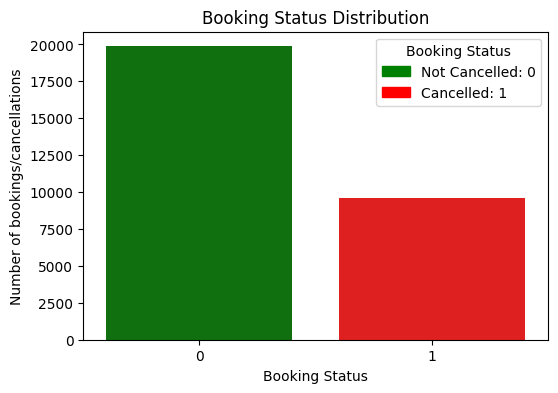

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='booking_status', data=imputed_train, palette={0:'green', 1 : 'red'})
legend_handles = [Patch(color='green', label='Not Cancelled: 0'),Patch(color='red', label = 'Cancelled: 1')]
plt.title('Booking Status Distribution')
plt.xlabel('Booking Status')
plt.ylabel('Number of bookings/cancellations')
plt.legend(handles=legend_handles, title = 'Booking Status')
plt.show()

### **Inference from the Plot**

The distribution from the plot above shows more number of 'non-cancelled' bookings than 'cancelled' bookings. This suggests that customers usually complete their bookings rather than cancelling on them. However, the significant imbalance indicates that machine learning models may become biased toward predicting the majority class, so evaluation metrics such as F1-score, Recall/Precision or ROC-AUC would be more informative than accuracy.

## **Visualisation 2: Booking Status by Price**

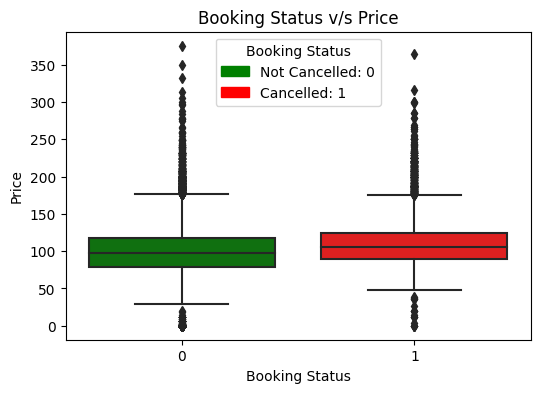

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x='booking_status', y='price', data=imputed_train, palette={0:'green', 1:'red'})
plt.title('Booking Status v/s Price')
plt.xlabel('Booking Status')
plt.ylabel('Price')
plt.legend(handles=legend_handles, title='Booking Status')
plt.show()

### **Inference from Plot**

The distribution from the plot shows the median price for the cancelled bookings (status = 1) is higher than for the not cancelled (status = 0) bookings. This suggests that bookings exhbiting higher prices are more likely to get cancelled. However, both groups overlap heavily, inferring that price influences cancellation to some degree, but it is not the strongest reason for cancellations.

## **Visualisation 3: Booking Status by Lead Time**

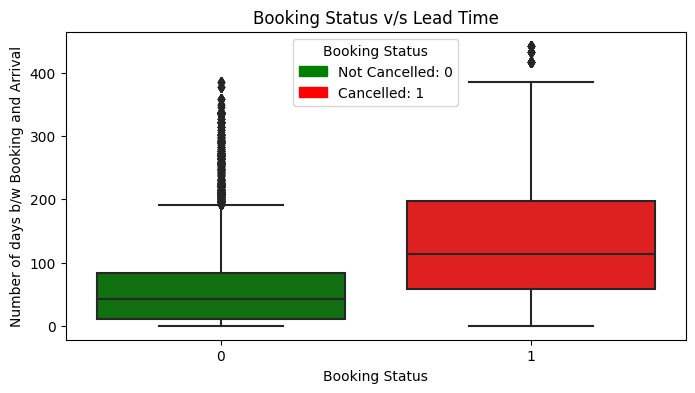

In [23]:
plt.figure(figsize=(8,4))
sns.boxplot(x='booking_status', y='lead_time', data=imputed_train, palette= {0:'green', 1:'red'})
plt.title('Booking Status v/s Lead Time')
plt.xlabel('Booking Status')
plt.ylabel('Number of days b/w Booking and Arrival')
plt.legend(handles=legend_handles, title='Booking Status')
plt.show()

### **Inference from the Plot**

The distribution from the plot shows a clear difference in lead time between bookings that were cancelled (1) and the ones that were not cancelled (0). Cancelled bookings have a higher median lead time of around more than 110 days, as compared to the non-cancelled bookings. This indicates that bookings that are made much further in advance are more likely to be cancelled eventually. Whereas, bookings with shorter lead time are more likely to be retained.

# **Rubrics 7: Scale Numerical features and Encode Categorical features**

Explanation for scaling (or not scaling) and encoding (or not encoding) is provided under this rubrics.

### **Step 1 : Dropping 'arrival' column and converting it to arrival_month**

The **arrival** column represents the date when the customer will arrive at the hotel, stored as a raw-string under the 'object' datatype. Since, machine learning models don't use date strings directly and the column information does not provide much significant impact on the booking status of customers, this column does not hold meaningful information in its current form. 

However, the **arrival** column when converted to datetime format can be useful if we extract the month out of it. This is because, hotel booking cancellations are often heavily inspired by the holiday season, where the months play a significant part.

Hence, the conclusion arrived was : **arrival column on its own doesn't add much to the modelling predictions thus it should be dropped, however, upon extracting arrival_month it improves the overall accuracy of the predictions, hence should be converted into month.**

In [24]:
imputed_train['arrival'] = pd.to_datetime(imputed_train['arrival'], errors='coerce')
imputed_train['arrival_month'] = imputed_train['arrival'].dt.month
imputed_train=imputed_train.drop(columns=['arrival'])
imputed_train['arrival_month'] = imputed_train['arrival_month'].fillna(imputed_train['arrival_month'].mode()[0])

imputed_test['arrival'] = pd.to_datetime(imputed_test['arrival'], errors='coerce')
imputed_test['arrival_month'] = imputed_test['arrival'].dt.month
imputed_test=imputed_test.drop(columns=['arrival'])
imputed_test['arrival_month'] = imputed_test['arrival_month'].fillna(imputed_test['arrival_month'].mode()[0])

### **Step 2: Defining the numerical columns and categorical columns separately**

In [25]:
cat_cols = ['room_type', 'meal_type', 'segment']
num_cols = ['lead_time', 'price', 'adults', 'children', 'weekends','weekdays','repeat','requests']

In [26]:
print(imputed_train['room_type'].unique())
print(imputed_train['meal_type'].unique())
print(imputed_train['segment'].unique())

['Room_Type 1' 'Room_Type 2' 'Room_Type 4' 'Room_Type 6' 'Room_Type 5'
 'Room_Type 7' 'Room_Type 3']
['Not Selected' 'Meal Plan 1' 'Meal Plan 2' 'Meal Plan 3']
['Online' 'Corporate' 'Offline' 'Complementary' 'Aviation']


### **Step 3: Scaling numerical columns and Encoding categorical values**

### **Scaling:**

* We avoid scaling the dataset as it contains some numeric columns which hold the values in a categorical format and scaling can destroy the natural splits on those columns. Besides, tree based models don't perform well on scaled datasets.
  
### **Encoding:**

* **OrdinalEncoder:** While the categorical variables do not have a natural order, OrdinalEncoder is appropriate for tree-based models because trees do not interpret encoded numbers as ranked values. Instead, they use them to group categories during splitting. Ordinal Encoding also keeps the dataset compact and works efficiently with tree models.

In [27]:
from sklearn.preprocessing import OrdinalEncoder

scale_encode = ColumnTransformer([
    ('cat', OrdinalEncoder(unknown_value=-1, handle_unknown='use_encoded_value'), cat_cols)
], remainder = 'passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

In [28]:
#creating datasets to fit the transformer
impxtrain = imputed_train.drop(columns=['booking_status'], axis=1)
impytrain = imputed_train['booking_status']

In [29]:
imputedx_train = scale_encode.fit_transform(impxtrain)
imputed_test = scale_encode.transform(imputed_test)

In [30]:
#adding the column 'booking_status' back to the train d
imputed_train = imputedx_train.copy()
imputed_train['booking_status'] = impy_train.values

In [31]:
#visualisation of scaling and encoding in train dataset
imputed_train.head()

,room_type,meal_type,segment,lead_time,price,id,adults,children,weekends,weekdays,repeat,requests,arrival_month,booking_status
0,0.0,3.0,4.0,54.0,116.10,0,2,0,0,1,0,0,5.0,1
1,0.0,3.0,4.0,12.0,71.87,1,1,0,3,6,0,1,11.0,1
2,1.0,0.0,4.0,34.0,71.55,2,2,0,0,2,0,1,1.0,0
3,0.0,0.0,2.0,4.0,66.00,3,1,0,2,1,1,0,2.0,0
4,0.0,0.0,3.0,155.0,72.25,4,2,0,2,3,0,0,7.0,0


In [32]:
#visualisation of scaling and encoding in test dataset
imputed_test.head()

,room_type,meal_type,segment,lead_time,price,id,adults,children,weekends,weekdays,repeat,requests,arrival_month
0,0.0,0.0,4.0,3.0,90.00,0,2,1,1,0,0,3,8.0
1,3.0,0.0,3.0,9.0,48.67,1,2,0,1,2,0,0,2.0
2,0.0,0.0,4.0,24.0,95.20,2,2,0,2,2,0,1,12.0
3,0.0,0.0,4.0,23.0,127.67,3,2,0,0,3,0,0,6.0
4,3.0,0.0,4.0,9.0,201.50,4,2,1,0,2,0,2,9.0


# **Rubrics 8 : Model Building (at least 7)**

7 different types of models are trained on the data under this rubrics.

## **Types of Models Used:**

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. Gradient Boosting Classifier
5. K-Neighbors Classifier
6. AdaBoost Classifier
7. MLPClassifier
8. SGDClassfier

In [33]:
imputed_train=imputed_train.drop(columns=['id'])
imputed_test=imputed_test.drop(columns=['id'])

### **Step 1: Train and validation dataset split**

In [34]:
from sklearn.model_selection import train_test_split

y = imputed_train['booking_status']
x = imputed_train.drop(columns=['booking_status'])

x_train, x_val, y_train, y_val = train_test_split(x,y,random_state=42, test_size=0.2, stratify=y)

### **Step 2: Importing and Defining Models**

In [35]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

In [36]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=500,class_weight='balanced', random_state=42),
    "Decision Tree" : DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest" : RandomForestClassifier(class_weight='balanced', random_state=42),
    "Stochastic Gradient Descent" : SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42),
    "K-Nearest Neighbors" : KNeighborsClassifier(),
    "AdaBoost" : AdaBoostClassifier(random_state=42),
    "Gradient Boosting" : GradientBoostingClassifier(random_state=42),
    "Multi-Layer Perceptron" : MLPClassifier(early_stopping=True)
}

### **Step 3: Training Models**

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

results = {}

for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_val)
    accuracy = accuracy_score(y_val,y_pred)
    f1 = f1_score(y_val,y_pred)
    results[name]={
        "Accuracy" : accuracy,
        "F1 Score" : f1
    }

    print(f'Model: {name}')
    print(f'Accuracy: {accuracy}')
    print(f'F1_Score: {f1}')
    print("Classfication Report:")
    print("")
    print(classification_report(y_val,y_pred, zero_division=0))
    print("-" * 55)

Model: Logistic Regression
Accuracy: 0.7684745762711864
F1_Score: 0.6852534562211983
Classfication Report:

              precision    recall  f1-score   support

           0       0.87      0.77      0.82      3974
           1       0.62      0.77      0.69      1926

    accuracy                           0.77      5900
   macro avg       0.75      0.77      0.75      5900
weighted avg       0.79      0.77      0.77      5900

-------------------------------------------------------
Model: Decision Tree
Accuracy: 0.8454237288135593
F1_Score: 0.7680569684638859
Classfication Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      3974
           1       0.75      0.78      0.77      1926

    accuracy                           0.85      5900
   macro avg       0.82      0.83      0.83      5900
weighted avg       0.85      0.85      0.85      5900

-------------------------------------------------------
Model: Random Forest
Acc

# **Rubrics 9: Hyperparameter Tuning on any 3 of the models**

Hyperparameter tuning is done on 3 of the models under this rubrics.

In [38]:
from sklearn.model_selection import GridSearchCV

## **Choice of Models for Hyperparameter Tuning**

### **1. Random Forest:** 

This model currently produces the best accuracy score with its **accuracy value ~ 0.886**, hence tuning this model will favour our results towards an even better score.

In [39]:
rf_param_grid={
    "n_estimators" : [800,1200],
    "max_depth" : [20,30,None],
    "min_samples_split" : [4,5],
    "min_samples_leaf" : [1,2],
    "max_features" : ['sqrt'],
}

rf=GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
               param_grid=rf_param_grid,
               scoring='accuracy', 
               cv=5,
               n_jobs=-1,
               verbose=1)

rf.fit(x_train,y_train)
rf_pred=rf.best_estimator_.predict(x_val)

print(f"Model : Random Forest (tuned)")
print(f"Accuracy Score : {accuracy_score(y_val,rf_pred)}")
print(f"Best Random Forest Parameters: {rf.best_params_}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Model : Random Forest (tuned)
Accuracy Score : 0.8883050847457628
Best Random Forest Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 1200}


### **2. Gradient Boosting:** 

This model currently produces the second best accuracy score with its **accuracy value ~ 0.847**. We know that, GradientBoostingClassifier usually jumps by a margin of 3-5% on parameter tuning, thus tuning this model will produce greater results with a better score.

In [40]:
gb_param_grid={
    "n_estimators" : [100,200,300],
    "learning_rate" : [0.05,0.1,0.2],
    "max_depth" : [3,4,5],
    "subsample" : [0.8,1.0]
}

gb=GridSearchCV(estimator=GradientBoostingClassifier(random_state=42),
               param_grid=gb_param_grid,
               scoring='accuracy',
               cv=3,
               n_jobs=-1,
               verbose=1)

gb.fit(x_train,y_train)
gb_pred = gb.best_estimator_.predict(x_val)

print(f"Model: GradientBoosting (tuned)")
print(f"Accuracy Score : {accuracy_score(y_val,gb_pred)}")
print(f"Best Gradient Boosting parameters: {gb.best_params_}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Model: GradientBoosting (tuned)
Accuracy Score : 0.8774576271186441
Best Gradient Boosting parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}


### **3. AdaBoost:** 

This model currently produces the third best accuracy score with its **accuracy value ~ 0.811**. Tuning this model is favourable due to its high accuracy score and performance.

In [41]:
ab_param_grid={
    "n_estimators" : [100,150,200],
    "learning_rate" : [0.5,1.0],
    "estimator" : [DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=2)]
}

ab=GridSearchCV(estimator=AdaBoostClassifier(random_state=42),
               param_grid=ab_param_grid,
               scoring='accuracy',
               cv=3,
               n_jobs=-1,
               verbose=1)

ab.fit(x_train, y_train)
ab_pred=ab.best_estimator_.predict(x_val)

print(f"Model: AdaBoost (tuned)")
print(f"Accuracy Score : {accuracy_score(y_val,ab_pred)}")
print(f"Best AdaBoost parameters: {ab.best_params_}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Model: AdaBoost (tuned)
Accuracy Score : 0.8559322033898306
Best AdaBoost parameters: {'estimator': DecisionTreeClassifier(max_depth=2), 'learning_rate': 1.0, 'n_estimators': 200}


# **Rubrics 10: Comparison of model performances**

Performance of the models on validation set is compared under this rubrics.

In [42]:
comparison_df=pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)
comparison_df

,Accuracy,F1 Score
Random Forest,0.886780,0.818872
Gradient Boosting,0.847288,0.749653
Decision Tree,0.845424,0.768057
Multi-Layer Perceptron,0.813051,0.690950
AdaBoost,0.811017,0.697258
K-Nearest Neighbors,0.798983,0.669085
Logistic Regression,0.768475,0.685253
Stochastic Gradient Descent,0.687627,0.644962


In [43]:
best_model_name = comparison_df.iloc[0]
print(f"Best model based on Accuracy: {'Random Forest'}")

Best model based on Accuracy: Random Forest


In [44]:
best_model = RandomForestClassifier(n_estimators=1800, min_samples_split=5, min_samples_leaf=1,
                                   max_depth=None, class_weight=None, max_features='sqrt',
                                   random_state=42)
best_model.fit(x_train, y_train)

predictions = best_model.predict(imputed_test)

# **Final Submission**

In [45]:
submission_df=pd.DataFrame({'id' : test_df['id'], 'booking_status': predictions})
submission_df.to_csv("submission.csv", index=False)